In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

print(df.shape)
print(df.head())

(42000, 785)
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0      

In [2]:
X = df.drop("label", axis=1)

y = df["label"]

print(X.shape)
print(y.shape)

(42000, 784)
(42000,)


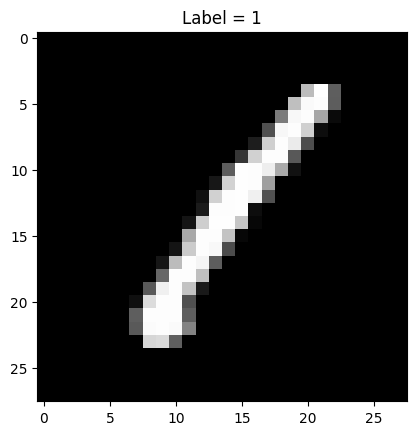

In [3]:
import matplotlib.pyplot as plt

image = X.iloc[0].values.reshape(28,28)

plt.imshow(image, cmap="gray")

plt.title(f"Label = {y.iloc[0]}")

plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
X_train = X_train / 255.0

X_test = X_test / 255.0

In [8]:
import tensorflow as tf

model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        128,
        activation="relu",
        input_shape=(784,)
    ),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )

])

In [9]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [10]:
history = model.fit(

    X_train,

    y_train,

    epochs=10,

    batch_size=32,

    validation_split=0.2

)

Epoch 1/10


840/840 [==============================] - 4s 3ms/step - loss: 0.3352 - accuracy: 0.9006 - val_loss: 0.2130 - val_accuracy: 0.9376
Epoch 2/10
840/840 [==============================] - 2s 2ms/step - loss: 0.1454 - accuracy: 0.9535 - val_loss: 0.1373 - val_accuracy: 0.9604
Epoch 3/10
840/840 [==============================] - 1s 2ms/step - loss: 0.0963 - accuracy: 0.9704 - val_loss: 0.1262 - val_accuracy: 0.9647
Epoch 4/10
840/840 [==============================] - 1s 2ms/step - loss: 0.0713 - accuracy: 0.9772 - val_loss: 0.1155 - val_accuracy: 0.9652
Epoch 5/10
840/840 [==============================] - 1s 2ms/step - loss: 0.0511 - accuracy: 0.9831 - val_loss: 0.1310 - val_accuracy: 0.9649
Epoch 6/10
840/840 [==============================] - 1s 2ms/step - loss: 0.0417 - accuracy: 0.9866 - val_loss: 0.1193 - val_accuracy: 0.9686
Epoch 7/10
840/840 [==============================] - 1s 2ms/step - loss: 0.0326 - accuracy: 0.9900 - val_loss: 0.1124 - val_accuracy: 0.9711
Epoc

In [11]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

263/263 [==============================] - 1s 2ms/step - loss: 0.1488 - accuracy: 0.9638
Accuracy: 0.9638095498085022
